<a href="https://colab.research.google.com/github/sajalgoyal007/AIML-Training-Projects/blob/main/Project1/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Email Spam Detection Project using Machine Learning**


##**About the Project**
At this modern time the email is widely use in the form of communication and we also professional, but it is also frequently targeted by spam messages/mail. Spam emails also contain advertisement, phising links, scams and unwanted content which is affect the user's experience and security.

The goal of this project is to build a Machine Learning model that can automatically classify emails as spam and not spam(ham) based on their content, subject. We analysing pattens in text messages and The model studies previously labeled emails and learns the difference between spam and genuine messages. Using this knowledge, it can predict whether a new email is spam or not.

In this project, the dataset will be explored and analyzed using Exploratory Data Analysis (EDA). The text data will then be cleaned and preprocessed using Natural Language Processing (NLP) techniques such as tokenization, stopword removal, and text vectorization. After preprocessing, machine learning algorithms will be trained and evaluated to determine the most effective model for spam detection.

The main objective of this project is to develop an accurate and reliable email spam detection system while gaining practical experience in data preprocessing, text classification, and machine learning workflows.

## **Step 1: Import Required Libraries**

In this step, we import all the necessary Python libraries required for data analysis, visualization, text preprocessing, machine learning model training, and evaluation. These libraries help us perform tasks such as handling datasets, creating visualizations, converting text into numerical features, training classification models, and measuring model performance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

##**Step 2:- Uploading CSV dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving spam mail.csv to spam mail.csv


##**Step 3:- Load the Dataset**

In this step, we load the dataset into the pandas dataframe, This dataset containing two columns: one representing the category of the message (Spam or Ham) and another containing the actual text message.

In [85]:
df = pd.read_csv('spam mail.csv')
df

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## **Step 3: Exploratory Data Analysis (EDA)**

Viewing the data

In [86]:
df.head()

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [87]:
df.tail()

,Category,Masseges
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [88]:
df.shape

(5572, 2)

In [89]:
df.columns

Index(['Category', 'Masseges'], dtype='object')

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [91]:
df.describe()

,Category,Masseges
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [92]:
df.isnull().sum()   # check for the null values

,0
Category,0
Masseges,0


In [93]:
df.duplicated().sum()  # Duplicate Value Analysis

np.int64(403)

In [94]:
df[df.duplicated()].head()

,Category,Masseges
102,ham,As per your request 'Melle Melle (Oru Minnamin...
153,ham,As per your request 'Melle Melle (Oru Minnamin...
206,ham,"As I entered my cabin my PA said, '' Happy B'd..."
222,ham,"Sorry, I'll call later"
325,ham,No calls..messages..missed calls


In [95]:
df.shape

(5572, 2)

In [96]:
df = df.drop_duplicates() #remove the duplicate rows

In [97]:
df.shape

(5169, 2)

In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
df.rename(columns={"Masseges": "message"},inplace=True)
df.head()

,Category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [100]:
df["Category"].value_counts()

,count
Category,
ham,4516
spam,653


In [101]:
df["Category"].value_counts(normalize=True) * 100

,proportion
Category,
ham,87.366996
spam,12.633004


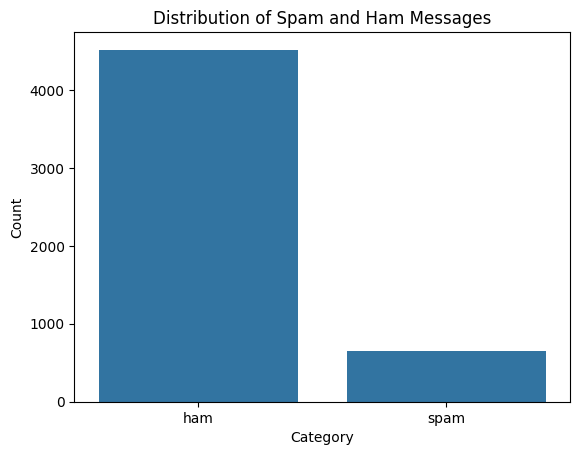

In [102]:
sns.countplot(x=df["Category"])

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [103]:
df["message_length"] = df["message"].apply(len)  # make a new columns whose name is message_length which store the length of the message

In [104]:
df.head()

,Category,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [105]:
df[["Category", "message_length"]].head()

,Category,message_length
0,ham,111
1,ham,29
2,spam,155
3,ham,49
4,ham,61


In [106]:
df.groupby("Category")["message_length"].mean()    # check the avg length of ham and spam messages

,message_length
Category,
ham,70.459256
spam,137.891271


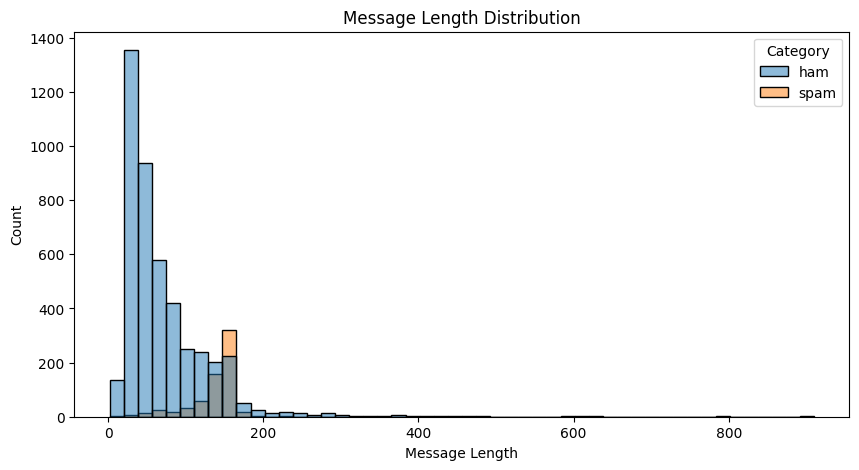

In [107]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="message_length",
    hue="Category",
    bins=50
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Count")

plt.show()

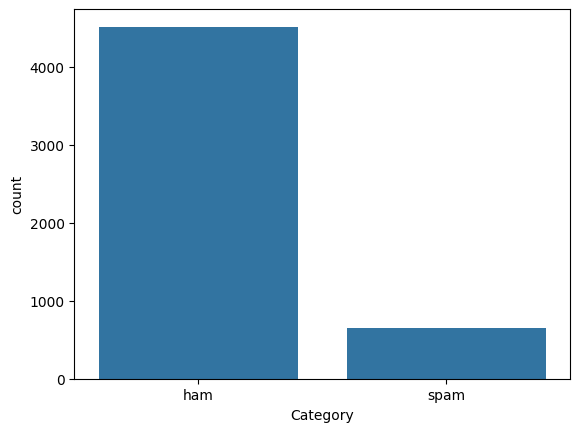

In [108]:
sns.countplot(x=df["Category"])
plt.show()

In [109]:
df["message_length"] = df["message"].apply(len)

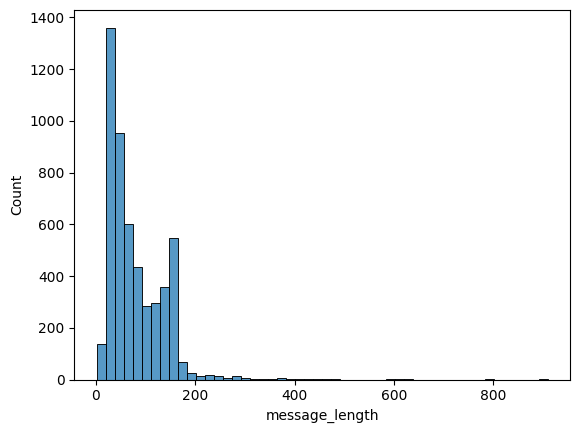

In [110]:
sns.histplot(df["message_length"], bins=50)
plt.show()

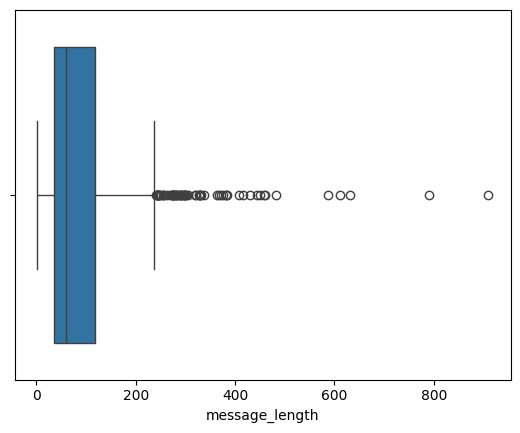

In [111]:
sns.boxplot(x=df["message_length"])
plt.show()

In [112]:
df.groupby("Category")["message_length"].mean()

,message_length
Category,
ham,70.459256
spam,137.891271


In [113]:
df["message_length"].describe()

,message_length
count,5169.000000
mean,78.977945
std,58.236293
min,2.000000
25%,36.000000
50%,60.000000
75%,117.000000
max,910.000000


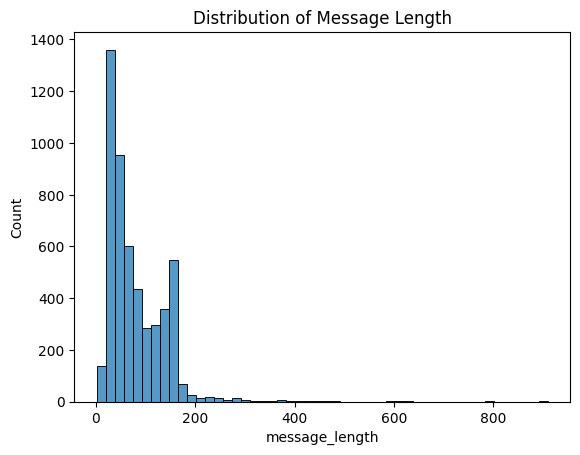

In [114]:
sns.histplot(df["message_length"], bins=50)
plt.title("Distribution of Message Length")
plt.show()

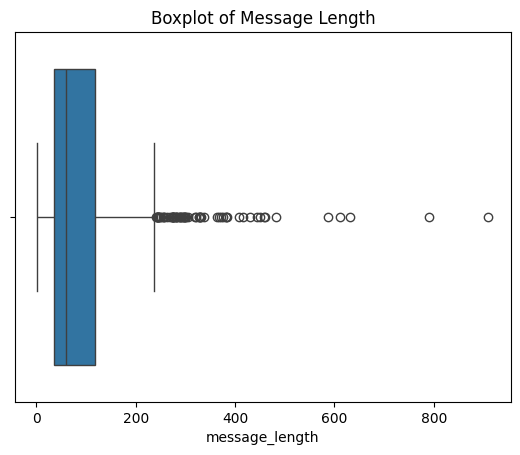

In [115]:
sns.boxplot(x=df["message_length"])
plt.title("Boxplot of Message Length")
plt.show()  ## Outlier Detection The boxplot helps identify unusually short or unusually long messages.

In [116]:
df["word_count"] = df["message"].apply(lambda x: len(str(x).split()))   # we split our each word from document

df[["Category", "word_count"]].head()

,Category,word_count
0,ham,20
1,ham,6
2,spam,28
3,ham,11
4,ham,13


In [117]:
df["word_count"].describe()

,word_count
count,5169.000000
mean,15.340685
std,11.068488
min,1.000000
25%,7.000000
50%,12.000000
75%,22.000000
max,171.000000


In [118]:
df.groupby("Category")["word_count"].mean()

,word_count
Category,
ham,14.134632
spam,23.681470


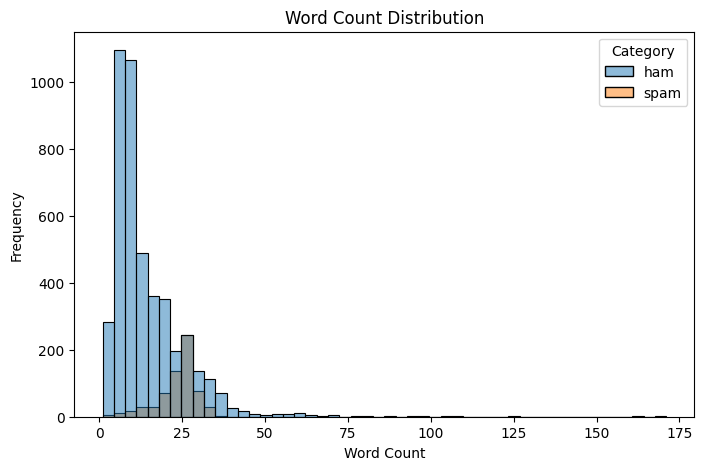

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="word_count",
    hue="Category",
    bins=50
)

plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

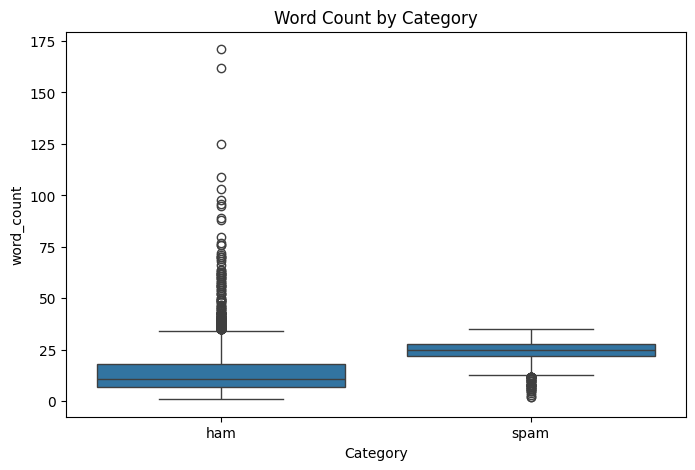

In [120]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Category",
    y="word_count"
)

plt.title("Word Count by Category")

plt.show()

In [121]:
all_words = " ".join(df["message"])

all_words[:500]

"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat... Ok lar... Joking wif u oni... Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's U dun say so early hor... U c already then say... Nah I don't think he goes to usf, he lives around here though FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you u"

In [122]:
from collections import Counter

words = all_words.lower().split()

word_freq = Counter(words)

word_freq.most_common(20)

[('i', 2095),
 ('to', 2055),
 ('you', 1832),
 ('a', 1281),
 ('the', 1223),
 ('and', 919),
 ('u', 890),
 ('in', 785),
 ('is', 766),
 ('my', 676),
 ('for', 653),
 ('your', 618),
 ('me', 579),
 ('of', 552),
 ('have', 532),
 ('on', 476),
 ('call', 468),
 ('are', 457),
 ('that', 453),
 ('it', 440)]

In [123]:
common_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

common_words

,Word,Frequency
0,i,2095
1,to,2055
2,you,1832
3,a,1281
4,the,1223
5,and,919
6,u,890
7,in,785
8,is,766
9,my,676


The most frequent words include common English stop words such as "to", "you", "the", and "and". Since these words do not provide meaningful information for spam classification, they will be removed during the text preprocessing stage before training the machine learning models.

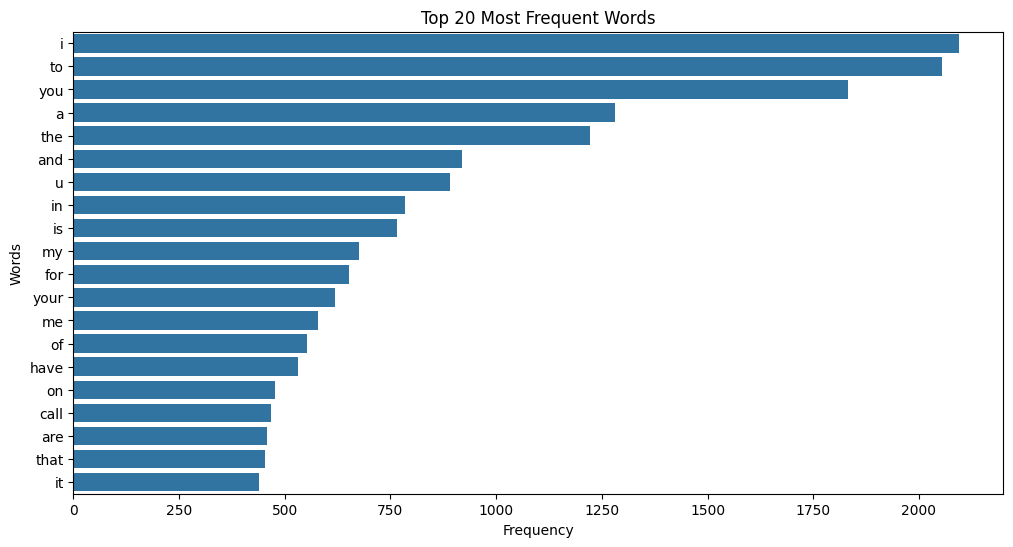

In [124]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=common_words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [125]:
!pip install wordcloud

In [126]:
from wordcloud import WordCloud

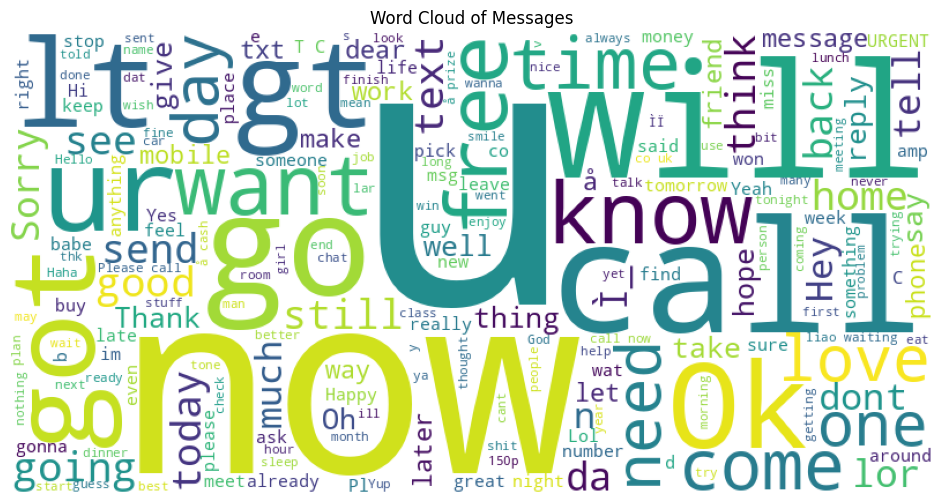

In [127]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Messages")
plt.show()

##**Step 4: Data Cleaning & Text Preprocessing**

### **Label Encoding**

Machine learning algorithms cannot directly understand text labels such as "spam" and "ham".

Therefore, we convert these categories into numerical values so that they can be used during model training.

In [128]:
df["Category"] = df["Category"].map({
    "ham": 0,
    "spam": 1
})  # because the model can not understand anything only know numbers that is 0 or 1

In [129]:
df.head()

,Category,message,message_length,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [130]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [131]:
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize  # to convert into the tokens

In [132]:
stemmer = PorterStemmer()

## Text Cleaning Function

Raw text often contains punctuation marks, special characters, stopwords, and words in different forms.

To prepare the text for machine learning, we perform:

- Lowercase conversion
- Tokenization
- Stopword removal
- Stemming

This process reduces noise and helps the model focus on meaningful information.

In [133]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = word_tokenize(text)

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stopwords.words("english")
    ]

    return " ".join(words)

In [134]:
df["clean_message"] = df["message"].apply(clean_text)

df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## **Step 5: Feature Extraction using TF-IDF**

Machine learning models cannot directly understand text data and the Project Spam Detection we use NLP (Natural Language Processing) whose best model in the ML is TF-IDF (Term Frequency - Inverse Document Frequency) is used to transform text into numerical feature vectors.

TF-IDF assigns higher importance to words that appear frequently in a particular message but are less common across the entire dataset.

In [135]:
vectorizer = TfidfVectorizer()

In [136]:
X = vectorizer.fit_transform(df["clean_message"])

In [137]:
y = df["Category"]

In [138]:
print(X.shape)
print(y.shape)

(5169, 6217)
(5169,)


## **Step 6: Train-Test Split**

To evaluate the model fairly, the dataset is divided into training and testing sets.

The training data is used to teach the model, while the testing data is used to evaluate how well the model performs on unseen messages.

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [140]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(4135, 6217)
(1034, 6217)
(4135,)
(1034,)


In the Model Ara Statical Machine Learning Approach there are three main algorithms Naive Bayes, Logistic Regression and SVM (Support Vector Machine) in the categorical data

## **Step 7: Naive Bayes Classifier**

Naive Bayes is one of the most commonly used algorithms for text classification problems such as spam detection.

It works on probability and is efficient for handling high-dimensional text data.

In [141]:
nb_model = MultinomialNB()  # we use multinominal bcz This algorithm evaluates the frequency of words

nb_model.fit(X_train, y_train)

MultinomialNB()

In [142]:
y_pred_nb = nb_model.predict(X_test)   #prediction

In [143]:
accuracy_score(y_test, y_pred_nb) #accuracy

0.9680851063829787

In [144]:
precision_score(y_test, y_pred_nb)   #precision

0.9912280701754386

In [145]:
recall_score(y_test, y_pred_nb)

0.7793103448275862

In [146]:
f1_score(y_test, y_pred_nb)

0.8725868725868726

In [148]:
cm = confusion_matrix(y_test, y_pred_nb)

cm

array([[888,   1],
       [ 32, 113]])

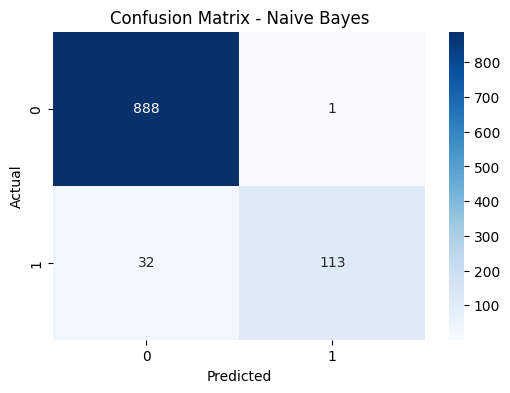

In [149]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##**Logistic Regression**

In [150]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

**Metrices**

In [151]:
accuracy_score(y_test, y_pred_lr)

0.9555125725338491

In [152]:
precision_score(y_test, y_pred_lr)

0.9459459459459459

In [153]:
recall_score(y_test, y_pred_lr)

0.7241379310344828

In [154]:
f1_score(y_test, y_pred_lr)

0.8203125

In [156]:
clr = confusion_matrix(y_test, y_pred_lr)
clr

array([[883,   6],
       [ 40, 105]])

##**SVM**

In [159]:
from sklearn.svm import SVC

In [160]:
SVM = SVC()

SVM.fit(X_train, y_train)

y_pred_svm = SVM.predict(X_test)

In [162]:
accuracy_score(y_test, y_pred_svm)

0.9758220502901354

In [172]:
precision_score(y_test, y_pred_svm)

1.0

In [164]:
recall_score(y_test, y_pred_svm)

0.8275862068965517

In [165]:
f1_score(y_test, y_pred_svm)

0.9056603773584906

In [166]:
csvc = confusion_matrix(y_test, y_pred_svm)
csvc

array([[889,   0],
       [ 25, 120]])

##**Random Forest**

In [167]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [168]:
accuracy_score(y_test, y_pred_rf)

0.9748549323017408

In [169]:
precision_score(y_test, y_pred_rf)

0.9917355371900827

In [170]:
recall_score(y_test, y_pred_rf)

0.8275862068965517

In [171]:
f1_score(y_test, y_pred_rf)

0.9022556390977443

# **Model Comparison**

Four machine learning models were trained and evaluated for email spam detection:

1. Naive Bayes
2. Logistic Regression
3. SVM
4. Random Forest

Among all models, Support Vector Classifier achieved the best performance with an accuracy of 97.58%, precision of 100%, recall of 82.76%, and F1-score of 90.56%.

The results indicate that Support Vector Classifier was able to classify spam and ham messages more effectively than the other models while maintaining a strong balance between precision and recall.

Therefore, SVC (Support Vector Classifier) was selected as the final model for this project.

In [174]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        96.81,
        95.55,
        97.58,
        97.49
    ],
    "Precision": [
        99.12,
        94.59,
        100,
        99.17
    ],
    "Recall": [
        77.93,
        72.41,
        82.76,
        82.76
    ],
    "F1 Score": [
        87.26,
        82.03,
        90.56,
        90.23
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,96.81,99.12,77.93,87.26
1,Logistic Regression,95.55,94.59,72.41,82.03
2,SVM,97.58,100.00,82.76,90.56
3,Random Forest,97.49,99.17,82.76,90.23


# Testing the Model on New Messages

In this section, a user can enter a new message and the trained model will predict whether it is spam or ham.

In [175]:
def predict_spam(message):

    cleaned = clean_text(message)

    vectorized = vectorizer.transform([cleaned])

    prediction = rf_model.predict(vectorized)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [176]:
message = "Congratulations! You have won a free iPhone. Click here to claim your prize."

print(predict_spam(message))

SPAM


In [179]:
user_message = input("Enter your message: ")

result = predict_spam(user_message)

print("Prediction:", result)

Enter your message: Congratulations! You have won a free iPhone. Click here to claim your prize.
Prediction: SPAM
